#The DataFrame

The DataFrame is a tabular data structure very similar to the Spreadsheet (the most familiar are Excel spreadsheets). This data structure is designed to extend the case of the Series to multiple dimensions. In fact, the DataFrame consists of an ordered collection of columns, each of which can contain a value of different type (numeric, string, Boolean, etc.).

Unlike Series, which had an Index array containing labels associated with each element, in the case of the data frame, there are two index arrays. The first, associated with the lines, has very similar functions to the index array in Series. In fact, each label is associated with all the values in the row. The second array instead contains a series of labels, each associated with a particular column.

A DataFrame may also be understood as a dict of Series, where the keys are the column names and values are the Series that will form the columns of the data frame. Furthermore, all elements of each Series are mapped according to an array of labels, called Index.

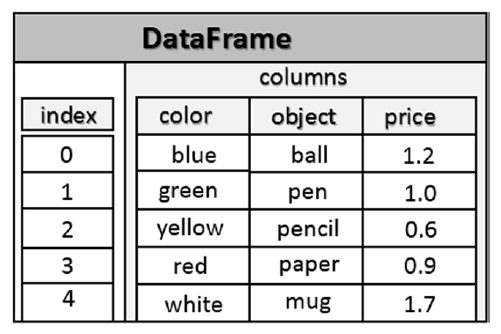

#Defining a DataFrame

The most common way to create a new DataFrame is precisely to pass a dict object to the DataFrame( ) constructor. This dict object contains a key for each column that we want to define, with an array of values for each of them.

In [ ]:
data = {'color' : ['blue','green','yellow','red','white'],
'object' : ['ball','pen','pencil','paper','mug'],
'price' : [1.2,1.0,0.6,0.9,1.7]}

In [ ]:
import pandas as pd
frame = pd.DataFrame(data)
frame

,color,object,price
0,blue,ball,1.2
1,green,pen,1.0
2,yellow,pencil,0.6
3,red,paper,0.9
4,white,mug,1.7


If the object dict from which we want to create a DataFrame contains more data than we are interested, you can make a selection. In the constructor of the data frame, you can specify a sequence of columns, using the columns option. The columns will be created in the order of the sequence regardless of how they are contained within the object dict.

In [ ]:
frame2 = pd.DataFrame(data, columns=['object','price'])
frame2

,object,price
0,ball,1.2
1,pen,1.0
2,pencil,0.6
3,paper,0.9
4,mug,1.7


Even for DataFrame objects, if the labels are not explicitly specified within the Index array, pandas automatically assigns a numeric sequence starting from 0. Instead, if you want to assign labels to the indexes of a DataFrame, you have to use the index option assigning it an array containing the labels.

In [ ]:
frame2 = pd.DataFrame(data, index=['one','two','three','four','five'])
frame2

,color,object,price
one,blue,ball,1.2
two,green,pen,1.0
three,yellow,pencil,0.6
four,red,paper,0.9
five,white,mug,1.7


Now that we have introduced the two new options index and columns, it is easy to imagine an alternative way to define a DataFrame. Instead of using a dict object, you can define within the constructor three arguments, in the following order: a data matrix, then an array containing the labels assigned to the index option, and finally an array containing the names of the columns assigned to the columns option.

In many examples, as you will see from now on in this book, to create quickly and easily a matrix of values you can use np.arange(16).reshape((4,4)) that generates a 4x4 matrix of increasing numbers from 0 to 15.

In [ ]:
import numpy as np
frame3 = pd.DataFrame(np.arange(16).reshape((4,4)), index=['red','blue','yellow','white'], columns=['ball','pen','pencil','paper'])
frame3

,ball,pen,pencil,paper
red,0,1,2,3
blue,4,5,6,7
yellow,8,9,10,11
white,12,13,14,15


#Selecting Elements

First, if we want to know the name of all the columns of a DataFrame is sufficient to specify the columns attribute on the instance of the DataFrame object.

In [ ]:
frame.columns

Index(['color', 'object', 'price'], dtype='object')

In [ ]:
#Similarly, to get the list of indexes, you should specify the index attribute.
frame.index

RangeIndex(start=0, stop=5, step=1)

As regards the values contained within the data structure, you can get the entire set of data using the values attribute.

In [ ]:
frame.values

array([['blue', 'ball', 1.2],
       ['green', 'pen', 1.0],
       ['yellow', 'pencil', 0.6],
       ['red', 'paper', 0.9],
       ['white', 'mug', 1.7]], dtype=object)

In [ ]:
#Or, if you are interested to select only the contents of a column, you can write the name of the column.
frame['price']

,price
0,1.2
1,1.0
2,0.6
3,0.9
4,1.7


In [ ]:
#As you can see, the return value is a Series object. Another way is to use the column name as an attribute of the instance of the DataFrame.
frame.price

,price
0,1.2
1,1.0
2,0.6
3,0.9
4,1.7


In [ ]:
frame

,color,object,price
0,blue,ball,1.2
1,green,pen,1.0
2,yellow,pencil,0.6
3,red,paper,0.9
4,white,mug,1.7


In [ ]:
frame.iloc[2]

,2
color,yellow
object,pencil
price,0.6


The object returned is again a Series, in which the names of the columns have become the label of the array index, whereas the values have become the data of Series.

In [ ]:
#To select multiple rows you specify an array with the sequence of rows to insert:
frame.iloc[[2,4]]

,color,object,price
2,yellow,pencil,0.6
4,white,mug,1.7


If you need to extract a portion of a DataFrame, selecting the lines that you want to extract, you can use the reference numbers of the indexes. In fact you can consider a row as a portion of a data frame that has the index of the row as the source (in the next 0) value and the line above the one we want as a second value (in the next one).

In [ ]:
frame[0:1]

,color,object,price
0,blue,ball,1.2


As you can see, the return value is an object data frame containing a single row. If you want more than one line, you must extend the selection range.

In [ ]:
frame[1:3]

,color,object,price
1,green,pen,1.0
2,yellow,pencil,0.6


Finally, if what you want to achieve is a single value within a DataFrame, first you have use the name of the column and then the index or the label of the row.

In [ ]:
frame['object'][3]

'paper'

#Assigning Values

Once you understand how to access the various elements that make up a DataFrame, just follow the same logic to add or change the values in it.

For example, you have already seen that within the DataFrame structure an array of indexes is specified by the index attribute, and the row containing the name of the columns is specified with the columns attribute. Well, you can also assign a label, using the name attribute, to these two substructures for identifying them.

In [ ]:
frame.index.name = 'id'; frame.columns.name = 'item'
frame

item,color,object,price
id,,,
0,blue,ball,1.2
1,green,pen,1.0
2,yellow,pencil,0.6
3,red,paper,0.9
4,white,mug,1.7


One of the best features of the data structures of pandas is their high flexibility. In fact you can always intervene at any level to change the internal data structure. For example, a very common operation is to add a new column.

You can do this by simply assigning a value to the instance of the DataFrame specifying a new column name.

In [ ]:
frame['new'] = 12
frame

item,color,object,price,new
id,,,,
0,blue,ball,1.2,12
1,green,pen,1.0,12
2,yellow,pencil,0.6,12
3,red,paper,0.9,12
4,white,mug,1.7,12


As you can see from the result, there is a new column called ‘new’ with the value within 12 replicated for each of its elements.

If, however, you want to do an update of the contents of a column, you have to use an array.

In [ ]:
frame['new'] = [3.0,1.3,2.2,0.8,1.1]
frame

item,color,object,price,new
id,,,,
0,blue,ball,1.2,3.0
1,green,pen,1.0,1.3
2,yellow,pencil,0.6,2.2
3,red,paper,0.9,0.8
4,white,mug,1.7,1.1


You can follow a similar approach if you want to update an entire column, for example, by using the
function np.arange( ) to update the values of a column with a predetermined sequence.

The columns of a data frame can also be created by assigning a Series to one of them, for example by
specifying a series containing an increasing series of values through the use of np.arange( ).

In [ ]:
ser = pd.Series(np.arange(5))
ser

,0
0,0
1,1
2,2
3,3
4,4


In [ ]:
frame['new'] = ser
frame

item,color,object,price,new
id,,,,
0,blue,ball,1.2,0
1,green,pen,1.0,1
2,yellow,pencil,0.6,2
3,red,paper,0.9,3
4,white,mug,1.7,4


Finally, to change a single value, simply select the item and give it the new value.

In [ ]:
frame['price'][2] = 3.3
frame

/tmp/ipykernel_961/2690994415.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  frame['price'][2] = 3.3
/tmp/ipykernel_961/2690994415.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the

item,color,object,price,new
id,,,,
0,blue,ball,1.2,0
1,green,pen,1.0,1
2,yellow,pencil,3.3,2
3,red,paper,0.9,3
4,white,mug,1.7,4


#Membership of a Value

You have already seen the function isin( ) applied to the Series to decide the membership of a set of values. Well, this feature is also applicable on DataFrame objects.

In [ ]:
frame

item,color,object,price,new
id,,,,
0,blue,ball,1.2,0
1,green,pen,1.0,1
2,yellow,pencil,3.3,2
3,red,paper,0.9,3
4,white,mug,1.7,4


In [ ]:
frame.isin([1.0,'pen'])

item,color,object,price,new
id,,,,
0,False,False,False,False
1,False,True,True,True
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False


You get a DataFrame containing only Boolean values, where True has only the values that meet the membership. If you pass the value returned as a condition then you’ll get a new DataFrame containing only the values that satisfy the condition.

In [ ]:
frame[frame.isin([1.0,'pen'])]

item,color,object,price,new
id,,,,
0,NaN,NaN,NaN,NaN
1,NaN,pen,1.0,1.0
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


#Deleting a Column

If you want to delete an entire column with all its contents, then use the del command.

In [ ]:
del frame['new']
frame

item,color,object,price
id,,,
0,blue,ball,1.2
1,green,pen,1.0
2,yellow,pencil,3.3
3,red,paper,0.9
4,white,mug,1.7


#Filtering

Even for a DataFrame you can apply the filtering through the application of certain conditions, for example if you want to get all values smaller than a certain number, for example 12.

In [ ]:
frame[frame['price'] < 1]

item,color,object,price
id,,,
3,red,paper,0.9


In [ ]:
frame['price'] < 1

,price
id,
0,False
1,False
2,False
3,True
4,False


#DataFrame from Nested dict

A very common data structure used in Python is a nested dict, as the one represented as follows:

In [ ]:
nestdict = { 'red': { 2012: 22, 2013: 33 },
'white': { 2011: 13, 2012: 22, 2013: 16},
'blue': {2011: 17, 2012: 27, 2013: 18}}

In [ ]:
frame2 = pd.DataFrame(nestdict)
frame2

,red,white,blue
2012,22.0,22,27
2013,33.0,16,18
2011,NaN,13,17


#Transposition of a DataFrame

An operation that might be needed when dealing with tabular data structures is the transposition (that is, the columns become rows and rows columns). pandas allows you to do this in a very simple way. You can get the transpose of the data frame by adding the T attribute to its application.

In [ ]:
frame2.T

,2012,2013,2011
red,22.0,33.0,NaN
white,22.0,16.0,13.0
blue,27.0,18.0,17.0


#The Index Objects

Now that you know what the Series and the data frame are and how they are structured, you can certainly perceive the peculiarities of these data structures. Indeed, the majority of their excellent characteristics in the data analysis are due to the presence of an Index object totally integrated within these data structures.

The Index objects are responsible for the labels on the axes and other metadata as the name of the axes. You have already seen as an array containing labels is converted into an Index object: you need to specify the index option within the constructor.

In [ ]:
ser = pd.Series([5,0,3,8,4], index=['red','blue','yellow','white','green'])
ser.index

Index(['red', 'blue', 'yellow', 'white', 'green'], dtype='object')

In [ ]:
ser.values

array([5, 0, 3, 8, 4])

In [ ]:
ser

,0
red,5
blue,0
yellow,3
white,8
green,4


Unlike all other elements within pandas data structures (Series and data frame), the Index objects are immutable objects. Once declared, these cannot be changed. This ensures their secure sharing between the various data structures.

Each Index object has a number of methods and properties especially useful when you need to know
the values they contain.

#Methods on Index

There are some specific methods for indexes available to get some information about index from a data structure. For example, idmin( ) and idmax( ) are two functions that return, respectively, the index with the lowest value and more.

In [ ]:
ser.idxmin()


'blue'

In [ ]:
ser.idxmax()

'white'

#Index with Duplicate Labels

So far, you have met all cases in which the indexes within a single data structure had the unique label. Although many functions require this condition to run, for the data structures of pandas this condition is not mandatory.

Define by way of example, a Series with some duplicate labels.

In [ ]:
serd = pd.Series(range(6), index=['white','white','blue','green','green','yellow'])
serd

,0
white,0
white,1
blue,2
green,3
green,4
yellow,5


Regarding the selection of elements within a data structure, if in correspondence of the same label there are more values, you will get a Series in place of a single element.


In [ ]:
serd['white']

,0
white,0
white,1


The same logic applies to the data frame with duplicate indexes that will return the data frame.

In the case of data structures with small size, it is easy to identify any duplicate indexes, but if the structure becomes gradually larger this starts to become difficult. Just in this respect, pandas provides you with the is_unique attribute belonging to the Index objects. This attribute will tell you if there are indexes with duplicate labels inside the structure data (both Series and DataFrame).

In [ ]:
serd.index.is_unique


False

In [ ]:
frame

item,color,object,price
id,,,
0,blue,ball,1.2
1,green,pen,1.0
2,yellow,pencil,3.3
3,red,paper,0.9
4,white,mug,1.7


In [ ]:
frame.index.is_unique

True

#Other Functionalities on Indexes

Compared to data structures commonly used with Python, you saw that pandas, as well as taking advantage of the high-performance quality offered by NumPy arrays, has chosen to integrate indexes within them.

This choice has proven somewhat successful. In fact, despite the enormous flexibility given by the
dynamic structures that already exist, the capability to use the internal reference to the structure, such as that offered by the labels, allows those who must perform operations to carry out in a much more simple and direct way a series of operations that you will see in this and the next chapter.

In this section you will analyze in detail a number of basic features that take advantage of  
mechanism of the indexes.

• Reindexing

• Dropping

• Alignment

#Reindexing

It was previously stated that once declared within a data structure, the Index object cannot be changed. This is true, but by executing a reindexing you can also overcome this problem.

In fact it is possible to obtain a new data structure from an existing one where indexing rules can be defined again.

In [ ]:
ser = pd.Series([2,5,7,4], index=['one','two','three','four'])
ser

,0
one,2
two,5
three,7
four,4


In order to make the reindexing of this series, pandas provides you with the reindex( ) function.
This function creates a new Series object with the values of the previous Series rearranged according to the new sequence of labels.

During this operation of reindexing, it is therefore possible to change the order of the sequence of indexes, delete some of them, or add new ones. In the case of a new label, pandas add NaN as corresponding value.

In [ ]:
ser.reindex(['three','four','five','one'])

,0
three,7.0
four,4.0
five,NaN
one,2.0


As you can see from the value returned, the order of the labels has been completely rearranged. The
value corresponding to the label ‘two’ has been dropped and a new label ‘five’ is present in the Series.

However, to measure the reindexing, the definition of the list of all the labels can be awkward, especially for a large data frame. So you could use some method that allows you to fill or interpolate values automatically.

To better understand the functioning of this mode of automatic reindexing, define the following Series.

In [ ]:
ser3 = pd.Series([1,5,6,3],index=[0,3,5,6])
ser3

,0
0,1
3,5
5,6
6,3


As you can see in this example, the index column is not a perfect sequence of numbers; in fact there are some missing values (1, 2, and 4). A common need would be to perform an interpolation in order to obtain the complete sequence of numbers. To achieve this you will use the reindexing with the method option set to ffill. Moreover, you need to set a range of values for indexes. In this case, for specifying a set of values between 0 and 5, you can use range(6) as argument.

In [ ]:
ser3.reindex(range(6),method='ffill')

,0
0,1
1,1
2,1
3,5
4,5
5,6


As you can see from the result, the indexes that were not present in the original Series were added. By interpolation, those with the lowest index in the original Series, have been assigned as values. In fact the indexes 1 and 2 have the value 1 which belongs to index 0.

If you want this index value to be assigned during the interpolation, you have to use the bfill method.

In [ ]:
ser3.reindex(range(6),method='bfill')

,0
0,1
1,5
2,5
3,5
4,6
5,6


In this case the value assigned to the indexes 1 and 2 is the value 5, which belongs to index 3.

Extending the concepts of reindexing with Series to the DataFrame, you can have a rearrangement not
only for indexes (rows), but also with regard to the columns, or even both. As previously mentioned, the addition of a new column or index is possible, but being missing values in the original data structure, pandas add NaN values to them.

In [ ]:
frame

item,color,object,price
id,,,
0,blue,ball,1.2
1,green,pen,1.0
2,yellow,pencil,3.3
3,red,paper,0.9
4,white,mug,1.7


In [ ]:
frame.reindex(range(5), method='ffill',columns=['colors','price','new','object'])

item,colors,price,new,object
id,,,,
0,blue,1.2,blue,ball
1,green,1.0,green,pen
2,yellow,3.3,yellow,pencil
3,red,0.9,red,paper
4,white,1.7,white,mug
